In [1]:
import json

from collections import Counter
import numpy as np

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

from textblob import TextBlob
import re 
import string

In [2]:
nltk.download('punkt')
nltk.download("stopwords")

STOPWORDS = set(stopwords.words("english"))

[nltk_data] Downloading package punkt to /Users/isabel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/isabel/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
try:
    with open('./dataProcessed/nurseNotes.json', 'r') as file:
        nurse_notes = json.load(file)
    print("File loaded successfully.")
    
except FileNotFoundError:
    print("Error: The file 'data.json' was not found.")

File loaded successfully.


In [4]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]
    return " ".join(words)


def tokenize(text):
    return clean_text(text).split()

In [5]:
def text_statistics(texts):
    lengths = [len(t) for t in texts]
    all_tokens = [tokenize(t) for t in texts]
    word_counts = [len(tok) for tok in all_tokens]

    all_words = [w for tok in all_tokens for w in tok]
    vocab = set(all_words)

    all_words = [w for t in texts for w in tokenize(t)]
    counter = Counter(all_words)

    ngrams = []
    for tokens in all_tokens:
        ngrams += zip(*[tokens[i:] for i in range(2)])

    counter_ngrams = Counter(ngrams)

    polarities = []
    for i, text in enumerate(texts[:5]):
        polarity = TextBlob(text).sentiment.polarity
        polarities.append(polarity)


    print("----- General Stats -----")
    print(f"Number of texts: {len(texts)}")
    print(f"Total words: {len(all_words)}")
    print(f"Unique words (vocab size): {len(vocab)}")

    print("----- Length Stats -----")
    print(f"Average text length (characters): {sum(lengths)/len(lengths)}")
    print(f"Average word count per text: {sum(word_counts)/len(word_counts)}")
    print(f"Shortest text word count: {min(word_counts)}")
    print(f"Longest text word count: {max(word_counts)}")

    print("----- Most Common N-GRAMS -----")
    for word, freq in counter_ngrams.most_common(10):
        print(f"{word} -> {freq}")

    print("----- Most Common Words -----")
    for gram, freq in counter.most_common(10):
        print("".join(gram), "->", freq)

    print("----- Sentiment -----")
    print(f"Average polarity: {np.array(polarities).mean()}")


In [6]:
def plot_word_distribution(texts):
    word_counts = [len(tokenize(t)) for t in texts]

    plt.figure()
    plt.hist(word_counts, bins=20)
    plt.title("Word Count Distribution per Text")
    plt.xlabel("Words per text")
    plt.ylabel("Frequency")
    plt.show()

In [7]:
def plot_top_words(texts, n):
    all_words = [w for t in texts for w in tokenize(t)]
    counter = Counter(all_words)
    common = counter.most_common(n)

    words = [w for w, _ in common]
    freqs = [f for _, f in common]

    plt.figure()
    plt.bar(words, freqs)
    plt.title("Most Common Words")
    plt.xticks(rotation=45)
    plt.show()

In [8]:
text_statistics(nurse_notes['P1'])

----- General Stats -----
Number of texts: 603
Total words: 8917
Unique words (vocab size): 721
----- Length Stats -----
Average text length (characters): 128.13930348258705
Average word count per text: 14.787728026533996
Shortest text word count: 2
Longest text word count: 80
----- Most Common N-GRAMS -----
('due', 'meds') -> 280
('meds', 'taken') -> 183
('resident', 'appears') -> 158
('care', 'needs') -> 155
('taken', 'charted') -> 144
('good', 'form') -> 133
('given', 'charted') -> 129
('assisted', 'care') -> 121
('meds', 'given') -> 111
('appears', 'good') -> 99
----- Most Common Words -----
resident -> 581
meds -> 324
care -> 322
due -> 310
charted -> 290
checks -> 261
assisted -> 241
appears -> 223
needs -> 216
taken -> 211
----- Sentiment -----
Average polarity: 0.2145833333333333


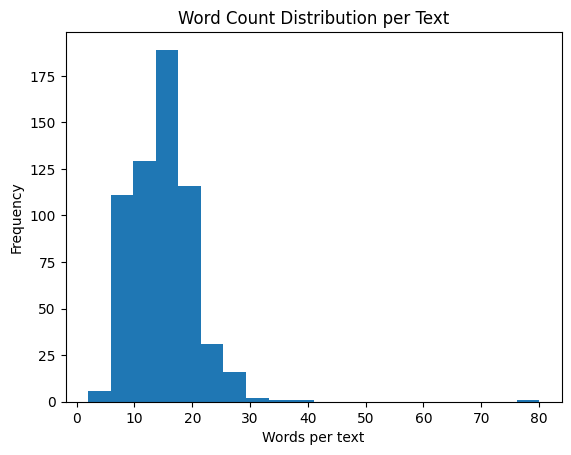

In [9]:
plot_word_distribution(nurse_notes['P1'])

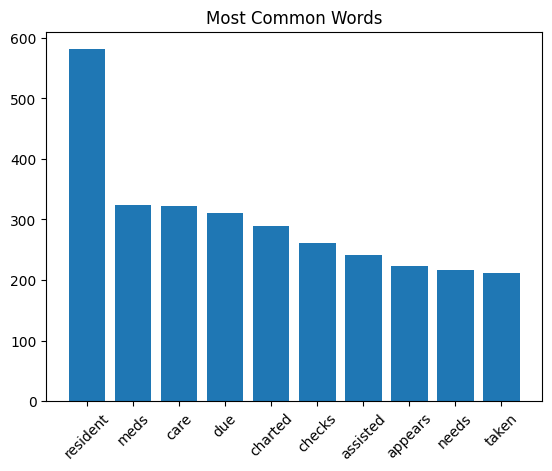

In [10]:
plot_top_words(nurse_notes['P1'], 10)